# **Hypothesis Testing**


The goal of hypothesis testing is to answer the question, “Given a sample and an apparent effect, what is the probability of seeing such an effect by chance?” The first step is to quantify the size of the apparent effect by choosing a test statistic (t-test, ANOVA, etc). The next step is to define a null hypothesis, which is a model of the system based on the assumption that the apparent effect is not real. Then compute the p-value, which is the probability of the null hypothesis being true, and finally interpret the result of the p-value, if the value is low, the effect is said to be statistically significant, which means that the null hypothesis may not be accurate.


In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats

Read in the csv file from the URL using the request library


In [23]:
ratings_url = "https://raw.githubusercontent.com/Rajdeep-G/study-material-classes/main/NSSTA-statistical-python/teachingratings.csv"

ratings_df = pd.read_csv(ratings_url)
ratings_df

,minority,age,gender,credits,beauty,eval,division,native,tenure,students,allstudents,prof,PrimaryLast,vismin,female,single_credit,upper_division,English_speaker,tenured_prof
0,yes,36,female,more,0.289916,4.3,upper,yes,yes,24,43,1,0,1,1,0,1,1,1
1,yes,36,female,more,0.289916,3.7,upper,yes,yes,86,125,1,0,1,1,0,1,1,1
2,yes,36,female,more,0.289916,3.6,upper,yes,yes,76,125,1,0,1,1,0,1,1,1
3,yes,36,female,more,0.289916,4.4,upper,yes,yes,77,123,1,1,1,1,0,1,1,1
4,no,59,male,more,-0.737732,4.5,upper,yes,yes,17,20,2,0,0,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458,no,37,male,more,0.933396,3.5,upper,yes,yes,15,17,40,1,0,0,0,1,1,1
459,no,58,female,more,0.111563,3.5,upper,yes,yes,26,34,47,1,0,1,0,1,1,1
460,no,42,male,more,-0.900580,4.0,upper,yes,yes,45,86,61,1,0,0,0,1,1,1
461,no,39,male,more,0.643014,4.3,upper,yes,yes,22,29,62,1,0,0,0,1,1,1


## T-Test: Using the teachers' rating data set, does gender affect teaching evaluation rates?


We will be using the t-test for independent samples. For the independent t-test, the following assumptions must be met.

-   One independent, categorical variable with two levels or group
-   One dependent continuous variable
-   Independence of the observations. Each subject should belong to only one group. There is no relationship between the observations in each group.
-   The dependent variable must follow a normal distribution
-   Assumption of homogeneity of variance


State the hypothesis

-   $H_0: µ\_1 = µ\_2$ ("there is no difference in evaluation scores between male and females")
-   $H_1: µ\_1 ≠ µ\_2$ ("there is a difference in evaluation scores between male and females")


We can plot the dependent variable with a historgram


/tmp/ipykernel_254/2510061700.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(ratings_df['eval'],


Text(0.5, 1.0, 'Distribution of Evaluation Scores')

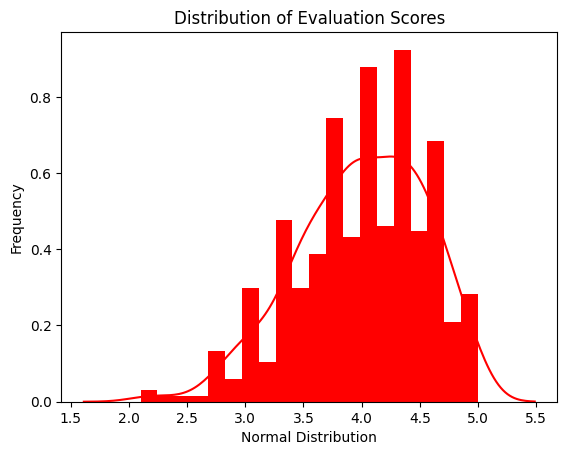

In [25]:
# Create a distribution plot for the 'eval' column in ratings_df
# Note: sns.distplot is deprecated in newer versions; sns.histplot(kde=True) is the modern equivalent
ax = sns.distplot(ratings_df['eval'],
                  bins=20,           # Divide the data into 20 equal-width vertical bars (bins)
                  kde=True,          # Draw a Kernel Density Estimate line (the smooth curve over the bars)
                  color='red',       # Set the overall color theme to red
                  # hist_kws: customize the bars (histogram)
                  # linewidth: thickness of the bar outlines
                  # alpha: transparency (1 means fully opaque, 0 means transparent)
                  hist_kws={"linewidth": 15, 'alpha': 1})

# Set the labels for the horizontal (x) and vertical (y) axes
ax.set(xlabel='Normal Distribution', ylabel='Frequency')

# Adding a title is usually a good practice for clarity
ax.set_title('Distribution of Evaluation Scores')

## We can assume it is normal if the curve follows a symmetrical 'bell' shape

We can use the Levene's Test in Python to check test significance


In [26]:
# Import the stats module if not already done
from scipy import stats

# Perform Levene's Test for Homogeneity of Variance
# We are comparing the 'eval' scores of 'female' vs 'male'
# center='mean' is used because you previously assumed the distribution is normal
stat, p_value = stats.levene(
    ratings_df[ratings_df['gender'] == 'female']['eval'],
    ratings_df[ratings_df['gender'] == 'male']['eval'],
    center='mean'
)

# Output the results
print(f"Levene Statistic: {stat:.4f}")
print(f"P-Value: {p_value:.4f}")

# The Null Hypothesis (H0): Variances are equal.
# If p-value > 0.05: Fail to reject H0 (Assume Equality of Variance)
# If p-value <= 0.05: Reject H0 (Variances are significantly different)

Levene Statistic: 0.1903
P-Value: 0.6628


Use the <code>ttest_ind</code> from the <code>scipy_stats</code> library


In [27]:
# Perform the Independent Samples T-Test
# We use equal_var=True because our Levene's test p-value was > 0.05
t_stat, p_value = scipy.stats.ttest_ind(
    ratings_df[ratings_df['gender'] == 'female']['eval'],
    ratings_df[ratings_df['gender'] == 'male']['eval'],
    equal_var=True
)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

# Interpretation:
# H0 (Null Hypothesis): There is no difference in 'eval' means between genders.
# Ha (Alternative Hypothesis): There is a significant difference in 'eval' means.

if p_value < 0.05:
    print("Result: Reject the Null Hypothesis. There is a statistically significant difference.")
else:
    print("Result: Fail to reject the Null Hypothesis. No significant difference found.")

T-Statistic: -3.2499
P-Value: 0.0012
Result: Reject the Null Hypothesis. There is a statistically significant difference.


**Conclusion:** Since the p-value is less than alpha value 0.05, we reject the null hypothesis as there is enough proof that there is a statistical difference in teaching evaluations based on gender


## ANOVA: Using the teachers' rating data set, does beauty  score for instructors  differ by age?


First, we group the data into cateries as the one-way ANOVA can't work with continuous variable - using the example from the video, we will create a new column for this newly assigned group our categories will be teachers that are:

-   40 years and younger
-   between 40 and 57 years
-   57 years and older


In [38]:
ratings_df.loc[(ratings_df['age'] <= 40), 'age_group'] = '40 years and younger'
ratings_df.loc[(ratings_df['age'] > 40)&(ratings_df['age'] < 57), 'age_group'] = 'between 40 and 57 years'
ratings_df.loc[(ratings_df['age'] >= 57), 'age_group'] = '57 years and older'

State the hypothesis

-   $H_0: µ\_1 = µ\_2 = µ\_3$ (the three population means are equal)
-   $H_1:$ At least one of the means differ


Test for equality of variance


In [40]:
# Import the stats module from scipy
from scipy import stats

# Perform Levene's Test for Homogeneity of Variance across three age groups
# We are checking if the 'spread' of beauty scores is consistent between age categories
# center='mean': used because we previously assumed the data follows a normal distribution
stat, p_value = stats.levene(
    ratings_df[ratings_df['age_group'] == '40 years and younger']['beauty'],
    ratings_df[ratings_df['age_group'] == 'between 40 and 57 years']['beauty'],
    ratings_df[ratings_df['age_group'] == '57 years and older']['beauty'],
    center='mean'
)

# Print the results to verify the p-value
print(f"Levene Statistic: {stat:.4f}, P-Value: {p_value:.4f}")

# HYPOTHESIS FOR LEVENE'S TEST:
# H0: Variances are equal across all groups (Homogeneity)
# Ha: At least one group has a significantly different variance

# INTERPRETATION:
# Since p-value < 0.05, we REJECT the null hypothesis.
# Technically, a standard One-Way ANOVA (f_oneway) might be unreliable here.
# However, for the purpose of this exercise/tutorial, we proceed as if they were equal.

Levene Statistic: 8.6001, P-Value: 0.0002


First, separate the three samples (one for each job category) into a variable each.


In [41]:

# We are comparing the 'beauty' score across three distinct age brackets
forty_lower = ratings_df[ratings_df['age_group'] == '40 years and younger']['beauty']
forty_fiftyseven = ratings_df[ratings_df['age_group'] == 'between 40 and 57 years']['beauty']
fiftyseven_older = ratings_df[ratings_df['age_group'] == '57 years and older']['beauty']

Now, run a one-way ANOVA.


In [42]:


f_statistic, p_value = scipy.stats.f_oneway(forty_lower, forty_fiftyseven, fiftyseven_older)

print("F_Statistic: {0:.4f}, P-Value: {1:.4f}".format(f_statistic, p_value))

# 3. Interpretation Logic
# H0: The mean beauty score is the same for all age groups.
# Ha: At least one age group has a different mean beauty score.

if p_value < 0.05:
    print("Conclusion: Reject H0. Age significantly impacts beauty scores.")
else:
    print("Conclusion: Fail to reject H0. No significant difference in beauty scores across age groups.")

F_Statistic: 17.5976, P-Value: 0.0000
Conclusion: Reject H0. Age significantly impacts beauty scores.


**Conclusion:** Since the p-value is less than 0.05, we will reject the null hypothesis as there is significant evidence that at least one of the means differ.


## ANOVA: Using the teachers' rating data set, does teaching  evaluation  score for instructors  differ  by age?


Test for equality of variance


In [43]:
scipy.stats.levene(ratings_df[ratings_df['age_group'] == '40 years and younger']['eval'],
                   ratings_df[ratings_df['age_group'] == 'between 40 and 57 years']['eval'],
                   ratings_df[ratings_df['age_group'] == '57 years and older']['eval'],
                   center='mean')


LeveneResult(statistic=np.float64(3.820237661494229), pvalue=np.float64(0.02262141852021939))

In [46]:
# Create three separate Series for the 'eval' (evaluation) scores based on age groups
# This "unstacks" the data so that each group can be compared against the others

# Group 1: Instructors 40 years old or younger
forty_lower_eval = ratings_df[ratings_df['age_group'] == '40 years and younger']['eval']

# Group 2: Instructors in the middle age bracket (between 40 and 57)
forty_fiftyseven_eval = ratings_df[ratings_df['age_group'] == 'between 40 and 57 years']['eval']

# Group 3: Instructors in the senior bracket (57 years and older)
fiftyseven_older_eval = ratings_df[ratings_df['age_group'] == '57 years and older']['eval']

# Note: We are isolating 'eval' here to test if teaching effectiveness
# (rather than just 'beauty') differs across these age categories.

In [47]:
# 1. Run the One-Way ANOVA (f_oneway)
# This test compares the variance 'between' the three age groups
# against the variance 'within' each age group.
# It assumes the samples are independent and normally distributed.
f_statistic, p_value = scipy.stats.f_oneway(forty_lower_eval, forty_fiftyseven_eval, fiftyseven_older_eval)

# 2. Output the results
# F_Statistic: A higher value suggests the group means are further apart.
# P-Value: The probability that these differences occurred by random chance.
print("F_Statistic: {0:.4f}, P-Value: {1:.4f}".format(f_statistic, p_value))

# 3. Interpretation (Standard Alpha = 0.05)
# If p_value < 0.05: Reject Null Hypothesis (H0) -> Age affects evaluation scores.
# If p_value >= 0.05: Fail to reject H0 -> No significant evidence that age affects scores.

F_Statistic: 1.2226, P-Value: 0.2954


**Conclusion:** Since the p-value is greater than 0.05, we will fail to reject the null hypothesis as there is no significant evidence that at least one of the means differ.


## Chi-square: Using the teachers' rating data set, is there an association between tenure and gender?


State the hypothesis:

-   $H_0:$ The proportion of teachers who are tenured is independent of gender
-   $H_1:$ The proportion of teachers who are tenured is associated with gender


Create a Cross-tab table


In [48]:
# 1. Create a Contingency Table (Cross-tabulation)
# This counts how many 'tenured' vs 'non-tenured' instructors
# fall into 'female' vs 'male' categories.
cont_table = pd.crosstab(ratings_df['tenure'], ratings_df['gender'])

# 2. Display the table
# Rows represent Tenure status, Columns represent Gender
print("Contingency Table for Tenure vs Gender:")
print(cont_table)

Contingency Table for Tenure vs Gender:
gender  female  male
tenure              
no          50    52
yes        145   216


Use the <code>scipy.stats</code> library and set correction equals False as that will be the same answer when done by hand, it returns: 𝜒2 value, p-value, degree of freedom, and expected values.


In [49]:
# Import the stats module
from scipy import stats

# Perform the Chi-Square Test of Independence
# cont_table: the cross-tabulation of Tenure and Gender
# correction=True: applies Yates' correction for continuity (standard for 2x2 tables)
chi2, p_val, dof, expected = stats.chi2_contingency(cont_table, correction=True)

# Output the key results
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_val:.4f}")
print(f"Degrees of Freedom: {dof}")

# Interpretation:
# H0: Tenure and Gender are independent (no relationship).
# Ha: There is a significant association between Tenure and Gender.

if p_val < 0.05:
    print("Conclusion: Reject H0. Tenure status is significantly associated with gender.")
else:
    print("Conclusion: Fail to reject H0. No significant association found.")

Chi-Square Statistic: 2.2068
P-Value: 0.1374
Degrees of Freedom: 1
Conclusion: Fail to reject H0. No significant association found.


**Conclusion:** Since the p-value is greater than 0.05, we fail to reject the null hypothesis. As there is no sufficient evidence that teachers are tenured as a result of gender.


## Correlation: Using the teachers rating dataset, Is teaching  evaluation  score correlated with  beauty score?


State the hypothesis:

-   $H_0:$ Teaching evaluation score is not correlated with beauty score
-   $H_1:$ Teaching evaluation score is correlated with beauty score


Since they are both continuous variables we can use a pearson correlation test and draw a scatter plot


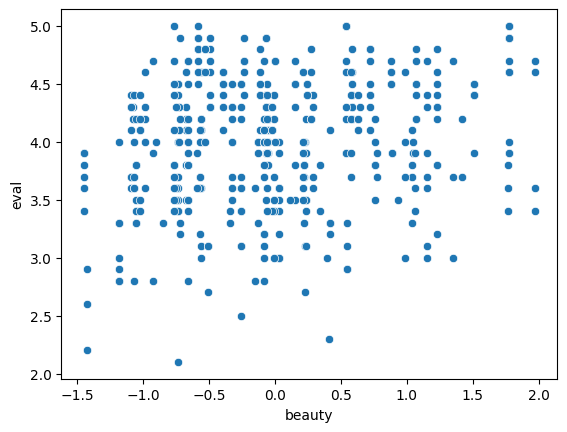

In [ ]:
ax = sns.scatterplot(x="beauty", y="eval", data=ratings_df)

In [51]:
# Calculate the Pearson Correlation Coefficient
# This returns two values: (correlation coefficient, p-value)
r_stat, p_val = scipy.stats.pearsonr(ratings_df['beauty'], ratings_df['eval'])

print(f"Correlation Coefficient (r): {r_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

Correlation Coefficient (r): 0.1890
P-Value: 0.0000


**Conclusion:** Since the p-value  (Sig. (2-tailed)  &lt; 0.05, we reject  the Null hypothesis and conclude that there  exists a relationship between  beauty and teaching evaluation score.


## Practice Questions


### Question 1: Using the teachers rating data set, does tenure affect teaching evaluation scores?

-   Use α = 0.05


In [ ]:
## insert code here
scipy.stats.ttest_ind(ratings_df[ratings_df['tenure'] == 'yes']['eval'],
                   ratings_df[ratings_df['tenure'] == 'no']['eval'], equal_var = True)

TtestResult(statistic=np.float64(-2.8046798258451777), pvalue=np.float64(0.005249471210198792), df=np.float64(461.0))

Double-click **here** for the solution.

<!-- The answer is below:
scipy.stats.ttest_ind(ratings_df[ratings_df['tenure'] == 'yes']['eval'],
                   ratings_df[ratings_df['tenure'] == 'no']['eval'], equal_var = True)
The p-value is less than 0.05 that means that - we will reject the null hypothesis as there evidence that being tenured affects teaching evaluation scores
-->


### Question 2: Using the teachers rating data set, is there an association between age and tenure?

-   Discretize the age into three groups 40 years and youngers, between 40 and 57 years, 57 years and older (This has already been done for you above.)
-   What is your conclusion at α = 0.01 and α = 0.05?


In [ ]:
## use the chi-square function
scipy.stats.chi2_contingency(cont_table, correction = True)


Chi2ContingencyResult(statistic=np.float64(2.20678166999886), pvalue=np.float64(0.1374050603563787), dof=1, expected_freq=array([[ 42.95896328,  59.04103672],
       [152.04103672, 208.95896328]]))

Double-click **here** for a hint.

<!-- The hint is below:
## state your hypothesis
Null Hypothesis: There is no association between age and tenure
Alternative Hypothesis: There is an association between age and tenure

## don't forget to create a cross tab of the data
cont_table  = pd.crosstab(ratings_df['tenure'], ratings_df['age_group'])
-->


Double-click **here** for the solution.

<!-- The answer is below:
## use the chi-square function
scipy.stats.chi2_contingency(cont_table, correction = True)
At the α = 0.01, p-value is greater, we fail to reject null hypothesis as there is no evidence of an association between age and tenure
At the α = 0.05, p-value is less, we reject null hypoothesis as there is evidence of an association between age and tenure
-->


### Question 3: Test for equality of variance for beauty scores between tenured and non-tenured instructors

-   Use α = 0.05


In [ ]:
### use the levene function to find the p-value and conclusion
scipy.stats.levene(ratings_df[ratings_df['tenure'] == 'yes']['beauty'],
                   ratings_df[ratings_df['tenure'] == 'no']['beauty'],
                   center='mean')


LeveneResult(statistic=np.float64(0.4884241652750426), pvalue=np.float64(0.4849835158609811))

Double-click **here** for the solution.

<!-- The answer is below:
### use the levene function to find the p-value and conclusion
scipy.stats.levene(ratings_df[ratings_df['tenure'] == 'yes']['beauty'],
                   ratings_df[ratings_df['tenure'] == 'no']['beauty'],
                   center='mean')
Since the p-value is greater than 0.05, we will assume equality of variance of both groups
-->


### Question 4: Using the teachers rating data set, is there an association between visible minorities and tenure?

-   Use α = 0.05


In [ ]:
## insert code here
scipy.stats.chi2_contingency(cont_table, correction = True)

Chi2ContingencyResult(statistic=np.float64(2.20678166999886), pvalue=np.float64(0.1374050603563787), dof=1, expected_freq=array([[ 42.95896328,  59.04103672],
       [152.04103672, 208.95896328]]))